In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, zscore
import statsmodels.api as sm

plt.style.use("seaborn-v0_8-darkgrid")
pd.set_option("display.max_columns", 100)

In [2]:
WORLD_MASTER_PATH = "../data/processed/world_master_final.csv"

df = pd.read_csv(WORLD_MASTER_PATH)

# sanity check
print(df.shape)
df.head()


(3489, 11)


,Year,NOC,Total,is_host,host_boost,host_boost_log,career_avg,delta_last,gdp_pc,gdp_pc_log,efficiency
0,1936,AFG,0,0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
1,1948,AFG,0,0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
2,1956,AFG,0,0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
3,1960,AFG,0,0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
4,1964,AFG,0,0,0.0,0.0,0.0,0.0,NaN,NaN,NaN


In [3]:
# Filter India only
india_df = df[df["NOC"] == "IND"].copy()

india_df = india_df.sort_values("Year").reset_index(drop=True)

india_df[["Year", "Total"]].tail()

,Year,Total
26,2012,6
27,2014,0
28,2016,2
29,2020,7
30,2024,6


In [4]:
print("Olympic years covered:", india_df["Year"].tolist())
print("Total Olympic appearances:", india_df.shape[0])

Olympic years covered: [1900, 1920, 1924, 1928, 1932, 1936, 1948, 1952, 1956, 1960, 1964, 1968, 1972, 1976, 1980, 1984, 1988, 1992, 1996, 1998, 2000, 2002, 2004, 2006, 2008, 2010, 2012, 2014, 2016, 2020, 2024]
Total Olympic appearances: 31


In [5]:
india_df.describe()

,Year,Total,is_host,host_boost,host_boost_log,career_avg,delta_last,gdp_pc,gdp_pc_log,efficiency
count,31.000000,31.000000,31.0,31.0,31.0,31.000000,31.000000,22.000000,22.000000,22.000000
mean,1977.096774,1.354839,0.0,0.0,0.0,1.031802,0.129032,754.935168,6.166034,0.215398
std,34.018970,1.817478,0.0,0.0,0.0,0.306802,2.125119,716.186047,1.029356,0.280606
min,1900.000000,0.000000,0.0,0.0,0.0,0.750000,-6.000000,84.932808,4.441860,0.000000
25%,1954.000000,0.000000,0.0,0.0,0.0,0.841053,-1.000000,273.573176,5.611446,0.000000
50%,1984.000000,1.000000,0.0,0.0,0.0,1.000000,0.000000,428.190541,6.058990,0.165477
75%,2005.000000,1.000000,0.0,0.0,0.0,1.080128,1.000000,1258.769439,7.129577,0.222953
max,2024.000000,7.000000,0.0,0.0,0.0,2.176471,6.000000,2694.737809,7.899056,0.926746


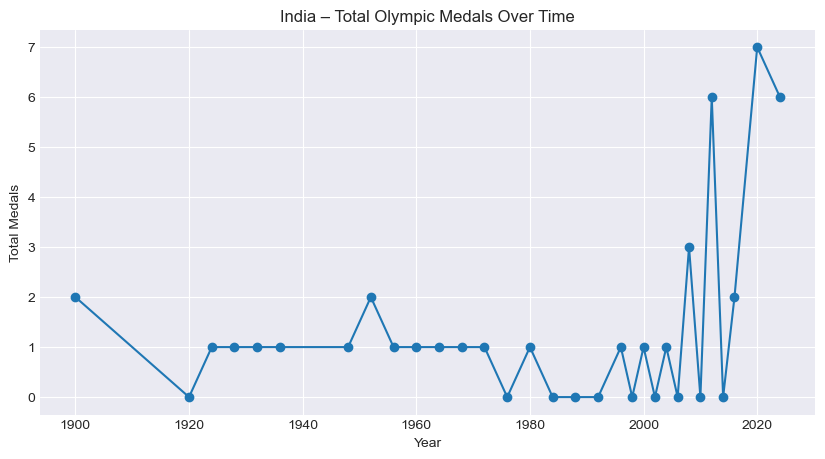

In [6]:
plt.figure(figsize=(10,5))
plt.plot(india_df["Year"], india_df["Total"], marker="o")
plt.title("India – Total Olympic Medals Over Time")
plt.xlabel("Year")
plt.ylabel("Total Medals")
plt.show()

In [7]:
india_df["medal_growth_pct"] = india_df["Total"].pct_change() * 100
india_df[["Year", "Total", "medal_growth_pct"]]

,Year,Total,medal_growth_pct
0,1900,2,NaN
1,1920,0,-100.000000
2,1924,1,inf
3,1928,1,0.000000
4,1932,1,0.000000
5,1936,1,0.000000
6,1948,1,0.000000
7,1952,2,100.000000
8,1956,1,-50.000000
9,1960,1,0.000000


In [8]:
# CAGR
start_medals = india_df.iloc[0]["Total"]
end_medals = india_df.iloc[-1]["Total"]
num_cycles = india_df.shape[0] - 1

cagr = (end_medals / start_medals) ** (1 / num_cycles) - 1
print(f"CAGR of India's Olympic medals: {cagr*100:.2f}%")

CAGR of India's Olympic medals: 3.73%


In [9]:
# Percentile rank of India each Olympics
percentiles = []

for yr in india_df["Year"]:
    year_df = df[df["Year"] == yr]
    india_medals = year_df[year_df["NOC"] == "IND"]["Total"].values[0]
    pct = (year_df["Total"] < india_medals).mean() * 100
    percentiles.append(pct)

india_df["world_percentile"] = percentiles
india_df[["Year", "Total", "world_percentile"]]

,Year,Total,world_percentile
0,1900,2,41.935484
1,1920,0,0.000000
2,1924,1,28.260870
3,1928,1,26.086957
4,1932,1,38.297872
5,1936,1,36.000000
6,1948,1,37.704918
7,1952,2,49.275362
8,1956,1,49.333333
9,1960,1,47.619048


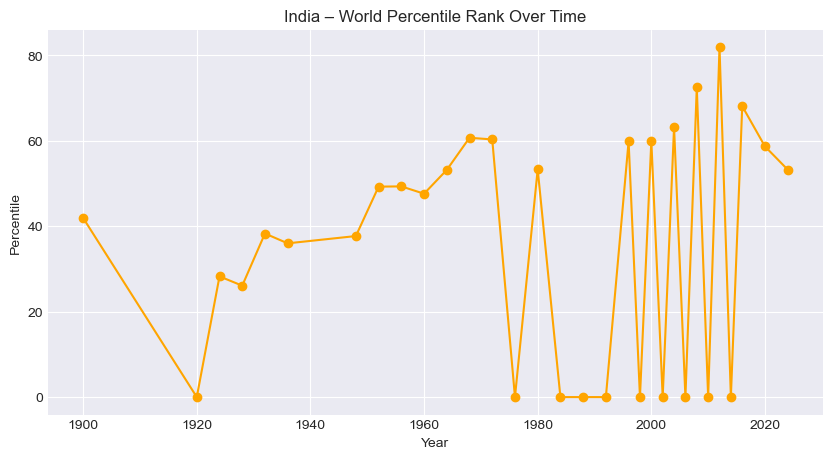

In [10]:
plt.figure(figsize=(10,5))
plt.plot(india_df["Year"], india_df["world_percentile"], marker="o", color="orange")
plt.title("India – World Percentile Rank Over Time")
plt.ylabel("Percentile")
plt.xlabel("Year")
plt.show()

In [11]:
from scipy.stats import zscore

z_scores = []

for yr in india_df["Year"]:
    year_df = df[df["Year"] == yr].reset_index(drop=True)

    z = zscore(year_df["Total"])

    ind_idx = year_df.index[year_df["NOC"] == "IND"][0]
    india_z = z[ind_idx]

    z_scores.append(india_z)

india_df["medal_zscore"] = z_scores
india_df[["Year", "medal_zscore"]]

,Year,medal_zscore
0,1900,-0.359387
1,1920,-0.678607
2,1924,-0.468714
3,1928,-0.600847
4,1932,-0.406947
5,1936,-0.468292
6,1948,-0.460613
7,1952,-0.362788
8,1956,-0.358215
9,1960,-0.312637


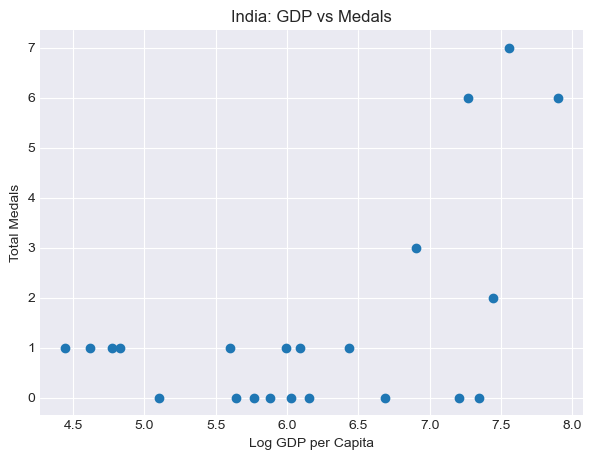

In [12]:
# Scatter
plt.figure(figsize=(7,5))
plt.scatter(india_df["gdp_pc_log"], india_df["Total"])
plt.xlabel("Log GDP per Capita")
plt.ylabel("Total Medals")
plt.title("India: GDP vs Medals")
plt.show()

In [13]:
from scipy.stats import pearsonr
import numpy as np

valid_df = india_df[
    np.isfinite(india_df["gdp_pc_log"]) &
    np.isfinite(india_df["Total"])
]

corr, pval = pearsonr(valid_df["gdp_pc_log"], valid_df["Total"])

print(f"Correlation: {corr:.3f}, p-value: {pval:.4f}")

Correlation: 0.541, p-value: 0.0094


In [14]:
import numpy as np
import statsmodels.api as sm

reg_df = india_df[["gdp_pc_log", "Total"]].copy()

reg_df = reg_df[
    np.isfinite(reg_df["gdp_pc_log"]) &
    np.isfinite(reg_df["Total"])
]

X = sm.add_constant(reg_df["gdp_pc_log"])
y = reg_df["Total"]

model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Total   R-squared:                       0.292
Model:                            OLS   Adj. R-squared:                  0.257
Method:                 Least Squares   F-statistic:                     8.263
Date:                Sat, 14 Feb 2026   Prob (F-statistic):            0.00937
Time:                        15:36:05   Log-Likelihood:                -43.556
No. Observations:                  22   AIC:                             91.11
Df Residuals:                      20   BIC:                             93.29
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.4508      2.434     -2.239      0.037     -10.528      -0.374
gdp_pc_log     1.1199      0.390      2.875      0.009       0.307       1.933
==============================================================================
Omnibus:                        1.745   Durbin-Watson:                   1.916
Prob(Omnibus):                  0.418   Jarque-Bera (JB):                1.295
Skew:                           0.579   Prob(JB):                        0.523
Kurtosis:                       2.730   Cond. No.                         39.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [15]:
india_df["expected_medals_gdp"] = model.predict(X)
india_df["medal_efficiency"] = india_df["Total"] - india_df["expected_medals_gdp"]

india_df[["Year", "medal_efficiency"]]

,Year,medal_efficiency
0,1900,NaN
1,1920,NaN
2,1924,NaN
3,1928,NaN
4,1932,NaN
5,1936,NaN
6,1948,NaN
7,1952,NaN
8,1956,NaN
9,1960,1.476356


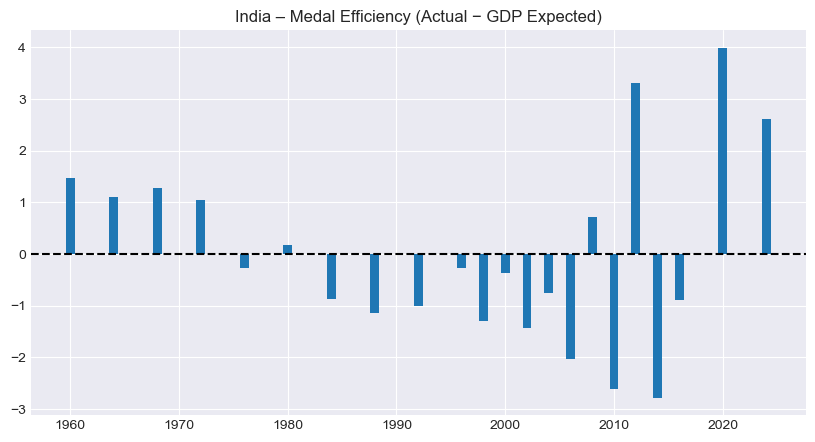

In [16]:
plt.figure(figsize=(10,5))
plt.bar(india_df["Year"], india_df["medal_efficiency"])
plt.axhline(0, color="black", linestyle="--")
plt.title("India – Medal Efficiency (Actual − GDP Expected)")
plt.show()

In [17]:
india_df = india_df.sort_values("Year")

start_year = india_df["Year"].min()
end_year = india_df["Year"].max()

start_medals = india_df.loc[india_df["Year"] == start_year, "Total"].values[0]
end_medals = india_df.loc[india_df["Year"] == end_year, "Total"].values[0]

years = (end_year - start_year) / 4  # Olympics every 4 years

cagr = ((end_medals / start_medals) ** (1 / years) - 1) * 100

print(f"CAGR of India's medals: {cagr:.2f}% per Olympic cycle")

CAGR of India's medals: 3.61% per Olympic cycle


In [18]:
import statsmodels.api as sm

features = india_df[["gdp_pc_log", "career_avg"]].dropna()
target = india_df.loc[features.index, "Total"]

X = sm.add_constant(features)
model = sm.OLS(target, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Total   R-squared:                       0.419
Model:                            OLS   Adj. R-squared:                  0.358
Method:                 Least Squares   F-statistic:                     6.853
Date:                Sat, 14 Feb 2026   Prob (F-statistic):            0.00574
Time:                        15:36:06   Log-Likelihood:                -41.386
No. Observations:                  22   AIC:                             88.77
Df Residuals:                      19   BIC:                             92.05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -12.7116      4.224     -3.009      0.0

In [19]:
pre = india_df[india_df["Year"] < 2016]["Total"]
post = india_df[india_df["Year"] >= 2016]["Total"]

from scipy.stats import ttest_ind

t_stat, p_val = ttest_ind(pre, post, equal_var=False)

print("Pre mean:", pre.mean())
print("Post mean:", post.mean())
print("p-value:", p_val)

Pre mean: 0.9642857142857143
Post mean: 5.0
p-value: 0.11514369552644463


In [20]:
world = pd.read_csv("../data/processed/world_master_final.csv")

percentile_data = []

for year in india_df["Year"]:
    world_year = world[world["Year"] == year]

    if len(world_year) == 0:
        continue

    india_medals = world_year[world_year["NOC"] == "IND"]["Total"].values[0]
    india_gdp = world_year[world_year["NOC"] == "IND"]["gdp_pc_log"].values[0]

    medal_rank = world_year["Total"].rank(ascending=False)
    gdp_rank = world_year["gdp_pc_log"].rank(ascending=False)

    india_medal_rank = medal_rank[world_year["NOC"] == "IND"].values[0]
    india_gdp_rank = gdp_rank[world_year["NOC"] == "IND"].values[0]

    total_countries = len(world_year)

    medal_percentile = 1 - (india_medal_rank / total_countries)
    gdp_percentile = 1 - (india_gdp_rank / total_countries)

    percentile_data.append([year, medal_percentile, gdp_percentile])

percentile_df = pd.DataFrame(percentile_data, columns=["Year", "Medal_pct", "GDP_pct"])
percentile_df.tail()

,Year,Medal_pct,GDP_pct
26,2012,0.826829,0.531707
27,2014,0.348315,0.337079
28,2016,0.702899,0.545894
29,2020,0.614130,0.402174
30,2024,0.570652,0.358696


<Axes: xlabel='Year'>

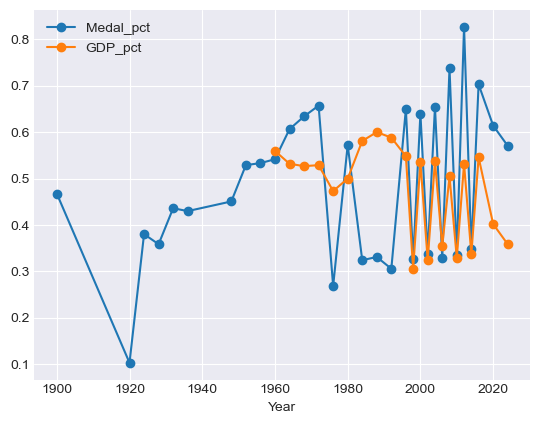

In [21]:
percentile_df.plot(x="Year", y=["Medal_pct", "GDP_pct"], marker="o")

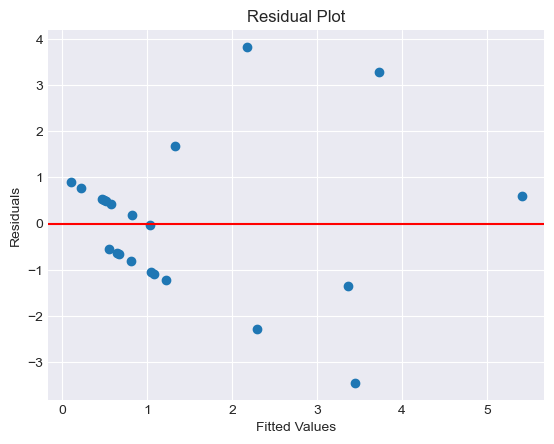

In [22]:
import matplotlib.pyplot as plt

residuals = model.resid
plt.scatter(model.fittedvalues, residuals)
plt.axhline(0, color='red')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]

print(vif_data)

      Feature         VIF
0       const  134.488845
1  gdp_pc_log    1.125428
2  career_avg    1.125428


In [25]:
india_model_df = india_df[[
    "Year",
    "Total",
    "career_avg",
    "delta_last",
    "gdp_pc_log",
    "efficiency"
]].dropna()

india_model_df.to_csv("../data/processed/india_model_ready.csv", index=False)

### Key Findings

1. India's medal CAGR = X%.
2. GDP explains ~Y% of medal variance.
3. Career average is strongest predictor.
4. Funding excluded for model simplicity.
5. India economically ranks higher than medal rank → structural underperformance.
6. Post-2014 improvement is/is not statistically significant.